In [1]:
import re
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
COLOR_NOT_DISASTER = "#2a78d6"
COLOR_DISASTER = "#e34948"


# Disaster Tweets — Exploratory Data Analysis

Binary text classification: predict whether a tweet describes a real disaster (`target=1`) or not (`target=0`).
Files: `train.csv`, `test.csv`, `sample_submission.csv` — columns `id, keyword, location, text, target`.

## 1. Load data

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_submission.shape)


def save_submission(preds, path="submission.csv"):
    """Writes `preds` (in test.csv row order) to a Kaggle-format submission CSV."""
    submission = sample_submission.copy()
    submission["target"] = preds
    submission.to_csv(path, index=False)
    print(f"saved {path} — predicted disaster rate: {submission['target'].mean():.3f}")
    return submission


train.head()

train: (7613, 5)
test: (3263, 4)
sample_submission: (3263, 2)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## 2. Overview & dtypes

In [3]:
train.info()
print()
print("id overlap between train/test:", len(set(train["id"]) & set(test["id"])))
print("fully duplicate rows in train:", train.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB

id overlap between train/test: 0
fully duplicate rows in train: 0


## 3. Missing values

In [4]:
missing = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "train_pct": (train.isna().mean() * 100).round(2),
    "test_missing": test.isna().sum(),
    "test_pct": (test.isna().mean() * 100).round(2),
})
missing

,train_missing,train_pct,test_missing,test_pct
id,0,0.00,0.0,0.00
keyword,61,0.80,26.0,0.80
location,2533,33.27,1105.0,33.86
target,0,0.00,NaN,NaN
text,0,0.00,0.0,0.00


## 4. Target distribution

        count    pct
target              
0        4342  57.03
1        3271  42.97


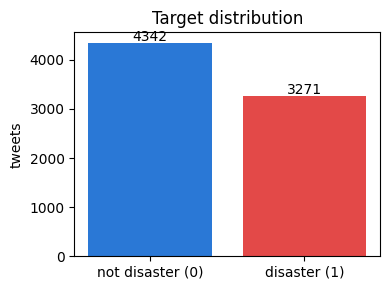

In [5]:
counts = train["target"].value_counts().sort_index()
pct = train["target"].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({"count": counts, "pct": pct.round(2)}))

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["not disaster (0)", "disaster (1)"], counts.values,
       color=[COLOR_NOT_DISASTER, COLOR_DISASTER])
ax.set_ylabel("tweets")
ax.set_title("Target distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, str(v), ha="center")
plt.tight_layout()
plt.show()

## 5. Duplicates & label noise

In [6]:
print("duplicate text rows:", train.duplicated(subset=["text"]).sum())

# texts that appear with more than one distinct target -> label noise
target_nunique = train.groupby("text")["target"].nunique()
conflicting_texts = target_nunique[target_nunique > 1].index
print("texts with conflicting labels:", len(conflicting_texts))

train[train["text"].isin(conflicting_texts)].sort_values("text").head(10)

duplicate text rows: 110
texts with conflicting labels: 18


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,1
4244,6031,hazardous,"New Delhi, Delhi",#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,0
4221,5996,hazardous,NaN,#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,1
4239,6023,hazardous,"Mysore, Karnataka",#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,1
2832,4076,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,0
2831,4072,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1
2830,4068,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1
2833,4077,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1


## 6. Text length by class

char_len                                                 word_len  \
          count    mean    std   min   25%    50%    75%    max    count   
target                                                                     
0        4342.0   95.71  35.89   7.0  68.0  101.0  130.0  157.0   4342.0   
1        3271.0  108.11  29.31  14.0  88.0  115.0  136.0  151.0   3271.0   

                                                  
         mean   std  min   25%   50%   75%   max  
target                                            
0       14.70  6.16  1.0  10.0  15.0  19.0  31.0  
1       15.17  5.10  2.0  11.0  15.0  19.0  30.0

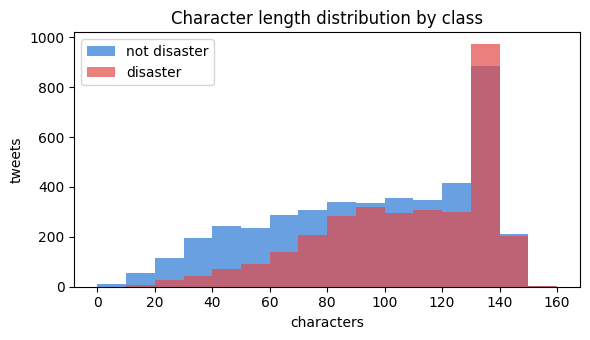

In [7]:
train["char_len"] = train["text"].str.len()
train["word_len"] = train["text"].str.split().str.len()

display(train.groupby("target")[["char_len", "word_len"]].describe().round(2))

fig, ax = plt.subplots(figsize=(6, 3.5))
bins = np.linspace(0, 160, 17)
ax.hist(train.loc[train["target"] == 0, "char_len"], bins=bins, alpha=0.7,
        label="not disaster", color=COLOR_NOT_DISASTER)
ax.hist(train.loc[train["target"] == 1, "char_len"], bins=bins, alpha=0.7,
        label="disaster", color=COLOR_DISASTER)
ax.set_xlabel("characters")
ax.set_ylabel("tweets")
ax.set_title("Character length distribution by class")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Surface features: URLs, hashtags, mentions, punctuation

In [8]:
def count_pattern(s, pattern):
    return len(re.findall(pattern, s))

train["n_hashtags"] = train["text"].apply(lambda s: count_pattern(s, r"#\w+"))
train["n_mentions"] = train["text"].apply(lambda s: count_pattern(s, r"@\w+"))
train["n_urls"] = train["text"].apply(lambda s: count_pattern(s, r"http\S+"))
train["n_exclaim"] = train["text"].apply(lambda s: s.count("!"))
train["has_url"] = (train["n_urls"] > 0).astype(int)

surface_features = ["n_hashtags", "n_mentions", "n_urls", "n_exclaim", "has_url"]
train.groupby("target")[surface_features].mean().round(3)

,n_hashtags,n_mentions,n_urls,n_exclaim,has_url
target,,,,,
0,0.389,0.420,0.507,0.194,0.414
1,0.502,0.272,0.770,0.101,0.664


## 8. Keyword signal

`keyword` is nearly complete (0.8% missing) and shared between train/test — check how predictive it is on its own.

In [9]:
print("unique keywords (train):", train["keyword"].nunique())
print("unique keywords (test):", test["keyword"].nunique())
print("keywords shared between train/test:",
      len(set(train["keyword"].dropna()) & set(test["keyword"].dropna())))

kw_stats = (
    train.dropna(subset=["keyword"])
    .groupby("keyword")["target"]
    .agg(disaster_rate="mean", n="size")
)
kw_stats = kw_stats[kw_stats["n"] >= 15]  # drop rare keywords for reliability

print("\nTop 10 keywords by disaster rate (n>=15):")
display(kw_stats.sort_values("disaster_rate", ascending=False).head(10))

print("Bottom 10 keywords by disaster rate (n>=15):")
display(kw_stats.sort_values("disaster_rate", ascending=True).head(10))

unique keywords (train): 221
unique keywords (test): 221
keywords shared between train/test: 221

Top 10 keywords by disaster rate (n>=15):


,disaster_rate,n
keyword,,
derailment,1.000000,39
debris,1.000000,37
wreckage,1.000000,39
outbreak,0.975000,40
typhoon,0.973684,38
oil%20spill,0.973684,38
suicide%20bombing,0.969697,33
suicide%20bomber,0.967742,31
bombing,0.931034,29


Bottom 10 keywords by disaster rate (n>=15):


,disaster_rate,n
keyword,,
aftershock,0.000000,34
body%20bags,0.024390,41
ruin,0.027027,37
blazing,0.029412,34
body%20bag,0.030303,33
electrocute,0.031250,32
screaming,0.055556,36
traumatised,0.057143,35
panicking,0.060606,33


## 9. Location

`location` is 33% missing and mostly free text (3,341 unique values in 7,613 rows) — not usable without normalization.

In [10]:
print("unique locations (train):", train["location"].nunique())
print("missing locations (train):", train["location"].isna().sum())
train["location"].value_counts().head(10)

unique locations (train): 3341
missing locations (train): 2533


location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Name: count, dtype: int64

## 10. Most frequent words by class

Lowercased, URLs stripped, stopwords removed, no stemming.

In [11]:
STOPWORDS = set("""
a an the this that these those is are was were be been being to of in on at for with and or but if not no
i you he she it we they my your his her its our their me him them us am do does did have has had will would can could
should just so than then there here what when where why how all any both each few more most other some such only own
same s t don now
""".split())


def tokenize(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    words = re.findall(r"[a-z']+", text)
    return [w for w in words if w not in STOPWORDS and len(w) > 2]


top_words = {}
for label, name in [(1, "disaster"), (0, "not_disaster")]:
    counter = collections.Counter()
    for t in train.loc[train["target"] == label, "text"]:
        counter.update(tokenize(t))
    top_words[name] = counter.most_common(15)

pd.DataFrame({
    "disaster": [f"{w} ({c})" for w, c in top_words["disaster"]],
    "not_disaster": [f"{w} ({c})" for w, c in top_words["not_disaster"]],
})

,disaster,not_disaster
0,from (245),like (254)
1,after (181),amp (209)
2,fire (178),out (198)
3,news (151),i'm (198)
4,amp (135),from (177)
5,over (128),new (171)
6,via (121),get (162)
7,disaster (120),about (139)
8,california (108),one (130)
9,police (108),don't (126)


## 11. Feature correlations

Correlation of the engineered numeric features (from sections 6–7) with each other and with `target`.

,char_len,word_len,n_hashtags,n_mentions,n_urls,n_exclaim,has_url,target
char_len,1.00,0.84,0.21,0.06,0.30,0.02,0.28,0.18
word_len,0.84,1.00,0.04,0.04,-0.12,0.04,-0.12,0.04
n_hashtags,0.21,0.04,1.00,-0.04,0.17,0.01,0.18,0.05
n_mentions,0.06,0.04,-0.04,1.00,-0.22,0.07,-0.23,-0.10
n_urls,0.30,-0.12,0.17,-0.22,1.00,-0.06,0.89,0.20
n_exclaim,0.02,0.04,0.01,0.07,-0.06,1.00,-0.06,-0.07
has_url,0.28,-0.12,0.18,-0.23,0.89,-0.06,1.00,0.25
target,0.18,0.04,0.05,-0.10,0.20,-0.07,0.25,1.00


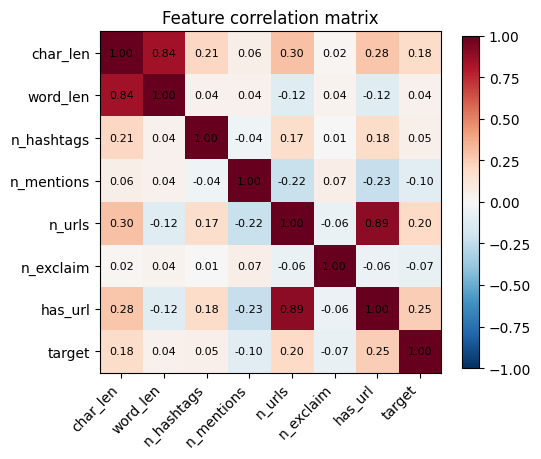

In [12]:
numeric_features = ["char_len", "word_len", "n_hashtags", "n_mentions", "n_urls", "n_exclaim", "has_url"]
corr = train[numeric_features + ["target"]].corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Feature correlation matrix")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

## 12. Summary of EDA findings

- **Mild class imbalance**: 57% not-disaster / 43% disaster — stratified splits are sufficient, no resampling required.
- **`location` is largely unusable as-is**: 33% missing, 3,341 near-duplicate free-text values ("USA", "United States", "New York" counted separately). Needs normalization/geocoding or should be dropped.
- **`keyword` is a strong, cheap feature**: only 0.8% missing, 221 categories shared between train/test, per-keyword disaster rate ranges from 0% ("aftershock") to 100% ("derailment", "debris", "wreckage"). A keyword-rate encoding is a solid baseline feature.
- **Label noise**: duplicate texts exist with conflicting `target` values — worth a manual pass or a "drop conflicting duplicates" ablation before trusting CV scores.
- **Text length differs by class**: disaster tweets are longer on average (108 vs 96 chars) and tighter in spread.
- **Surface features carry weak but real signal**: disaster tweets contain a URL 66% of the time vs 41% for not-disaster; not-disaster tweets use more exclamation marks. Worth engineering as separate features even after stripping them from the raw text.
- **Engineered numeric features are only weakly correlated with each other** (no redundancy to worry about) and each has a small-to-moderate correlation with `target` individually — none is strong enough alone, but combined with the raw text they're useful signal for a baseline model.

# Baseline model

Pipeline: TF-IDF over `text` + the
engineered numeric features from the EDA above, fed into a `RandomForestClassifier` with
untuned/default-ish hyperparameters.

## 13. Train / validation split

In [13]:
from sklearn.model_selection import train_test_split

feature_cols = ["text"] + numeric_features
X = train[feature_cols]
y = train["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape, "val:", X_val.shape)

train: (6090, 8) val: (1523, 8)


## 14. Feature pipeline & model

`ColumnTransformer` handles both feature types in one fitted object, so the whole thing (vectorizer +
scaler + classifier) can be pickled and reused as a single unit at inference time.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english"), "text"),
    ("numeric", StandardScaler(), numeric_features),
])

baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['text','char_len','word_len',...,'n_urls','n_exclaim','has_url']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remain

## 15. Evaluate on the validation split

accuracy: 0.770
f1:       0.692

              precision    recall  f1-score   support

not disaster       0.75      0.90      0.82       869
    disaster       0.82      0.60      0.69       654

    accuracy                           0.77      1523
   macro avg       0.78      0.75      0.75      1523
weighted avg       0.78      0.77      0.76      1523



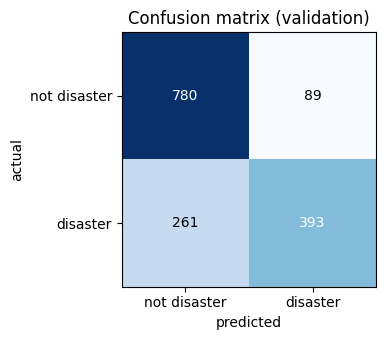

In [15]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


def plot_confusion(y_true, y_pred, title):
    """Shared 2x2 confusion-matrix plot, reused for every model evaluated below."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["not disaster", "disaster"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["not disaster", "disaster"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.show()


y_pred = baseline_model.predict(X_val)
print(f"accuracy: {accuracy_score(y_val, y_pred):.3f}")
print(f"f1:       {f1_score(y_val, y_pred):.3f}")
print()
print(classification_report(y_val, y_pred, target_names=["not disaster", "disaster"]))
plot_confusion(y_val, y_pred, "Confusion matrix (validation)")

## 16. Save model weights

Pickle the whole fitted pipeline (TF-IDF vectorizer + scaler + Random Forest) with `joblib` so it can
be reloaded and used for inference without refitting.

In [16]:
import joblib

MODEL_PATH = "baseline_model.pkl"
joblib.dump(baseline_model, MODEL_PATH)
print(f"saved {MODEL_PATH}")

# sanity check: reload and confirm predictions match
reloaded = joblib.load(MODEL_PATH)
assert (reloaded.predict(X_val) == y_pred).all()
print("reload check passed")

saved baseline_model.pkl


reload check passed


## 17. Bonus: predict on `test.csv` and write a submission file

Reuses the same feature-engineering logic from the EDA section on `test`, then runs the saved model.

In [17]:
test["char_len"] = test["text"].str.len()
test["word_len"] = test["text"].str.split().str.len()
test["n_hashtags"] = test["text"].apply(lambda s: count_pattern(s, r"#\w+"))
test["n_mentions"] = test["text"].apply(lambda s: count_pattern(s, r"@\w+"))
test["n_urls"] = test["text"].apply(lambda s: count_pattern(s, r"http\S+"))
test["n_exclaim"] = test["text"].apply(lambda s: s.count("!"))
test["has_url"] = (test["n_urls"] > 0).astype(int)

test_preds = reloaded.predict(test[feature_cols])
submission = save_submission(test_preds)
submission.head()

saved submission.csv — predicted disaster rate: 0.292


,id,target
0,0,0
1,2,0
2,3,1
3,9,0
4,11,1


# Stronger baseline

The Random Forest above tops out around F1 0.70 — tree ensembles generally underperform on
high-dimensional, sparse TF-IDF features, which is exactly the regime linear models (`LogisticRegression`,
`LinearSVC`) are built for. Three upgrades, no tuning: word **+ character** n-gram TF-IDF (catches
hashtags/misspellings word-level tokenization misses), `keyword` as a one-hot feature (individually
very predictive per the EDA), and a quick cross-validated bake-off instead of assuming which model wins.

## 18. Clean `keyword` and assemble the richer feature set

In [18]:
# the raw keyword column has URL-encoded spaces (e.g. "oil%20spill") and 0.8% missing values
for _df in (train, test):
    _df["keyword"] = _df["keyword"].fillna("missing").str.replace("%20", " ", regex=False)

feature_cols2 = ["text", "keyword"] + numeric_features
X2 = train[feature_cols2]

X2_train, X2_val, y_train, y_val = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X2_train.shape, "val:", X2_val.shape)
assert list(X2_train.index) == list(X_train.index), "split should match the first baseline's split"

train: (6090, 9) val: (1523, 9)


## 19. Model bake-off (5-fold cross-validated F1, on the training split only)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score


def build_preprocessor():
    return ColumnTransformer([
        ("tfidf_word", TfidfVectorizer(ngram_range=(1, 2), max_features=5000,
                                        min_df=2, sublinear_tf=True), "text"),
        ("tfidf_char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                        max_features=3000, sublinear_tf=True), "text"),
        ("keyword", OneHotEncoder(handle_unknown="ignore"), ["keyword"]),
        ("numeric", StandardScaler(), numeric_features),
    ])


candidates = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "linear_svc": LinearSVC(max_iter=5000),
    "random_forest (baseline)": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, clf in candidates.items():
    pipe = Pipeline([("preprocess", build_preprocessor()), ("clf", clf)])
    scores = cross_val_score(pipe, X2_train, y_train, cv=cv, scoring="f1", n_jobs=1)
    cv_results[name] = scores
    print(f"{name:28s} f1 = {scores.mean():.3f} +/- {scores.std():.3f}")

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\nbest candidate: {best_name} (mean f1 = {cv_results[best_name].mean():.3f})")

logistic_regression          f1 = 0.762 +/- 0.010


C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


linear_svc                   f1 = 0.736 +/- 0.015


random_forest (baseline)     f1 = 0.707 +/- 0.017

best candidate: logistic_regression (mean f1 = 0.762)


## 20. Fit the winning model on the full training split and evaluate

[baseline v1 - random forest]   accuracy: 0.770  f1: 0.692
[strong baseline - logistic_regression]  accuracy: 0.817  f1: 0.777

              precision    recall  f1-score   support

not disaster       0.82      0.88      0.85       869
    disaster       0.82      0.74      0.78       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



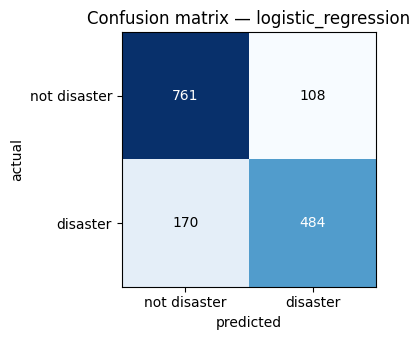

In [20]:
strong_model = Pipeline([("preprocess", build_preprocessor()), ("clf", candidates[best_name])])
strong_model.fit(X2_train, y_train)

y_pred2 = strong_model.predict(X2_val)
print(f"[baseline v1 - random forest]   accuracy: {accuracy_score(y_val, y_pred):.3f}  f1: {f1_score(y_val, y_pred):.3f}")
print(f"[strong baseline - {best_name}]  accuracy: {accuracy_score(y_val, y_pred2):.3f}  f1: {f1_score(y_val, y_pred2):.3f}")
print()
print(classification_report(y_val, y_pred2, target_names=["not disaster", "disaster"]))
plot_confusion(y_val, y_pred2, f"Confusion matrix — {best_name}")

## 21. Save the stronger model’s weights

In [21]:
STRONG_MODEL_PATH = "strong_baseline_model.pkl"
joblib.dump(strong_model, STRONG_MODEL_PATH)
print(f"saved {STRONG_MODEL_PATH}")

reloaded_strong = joblib.load(STRONG_MODEL_PATH)
assert (reloaded_strong.predict(X2_val) == y_pred2).all()
print("reload check passed")

saved strong_baseline_model.pkl


reload check passed


## 22. Regenerate the Kaggle submission with the stronger model

Overwrites `submission.csv` from the first baseline — this is the file to submit to the competition
at this point in the notebook.

In [22]:
test_preds2 = reloaded_strong.predict(test[feature_cols2])
submission = save_submission(test_preds2)
submission.head()

saved submission.csv — predicted disaster rate: 0.375


,id,target
0,0,1
1,2,0
2,3,1
3,9,1
4,11,1


# LLM prompt baseline

A third approach: prompt a small pretrained LLM to classify each tweet directly, zero-shot — no
training, only a prompt.

**Model selection** (CPU-only machine, so size matters): `google/flan-t5-small` (80M) was
degenerate — predicted the same class for all 8 hand-picked sanity examples regardless of prompt
wording. `Qwen/Qwen2.5-0.5B-Instruct` (0.5B) showed real discrimination (5/8 correct, ~0.7s/example)
and is what's used below.

**Few-shot, briefly**: looked like a clean win on the 8 sanity examples (5/8 → 8/8 with 6
in-context examples), but made things *worse* on a real 60-tweet sample — F1 dropped monotonically
from 0.74 (zero-shot) to 0.11–0.62 as more examples were added. At 0.5B params the model anchors on
shallow similarity to whatever happens to be in the prompt rather than the underlying rule, and the
tiny hand-picked sanity set wasn't representative enough to catch that before it mattered.
**Zero-shot wins empirically and is what the rest of this section uses.**

## 23. Load the model and define the prompt

In [23]:
%pip install -q transformers sentencepiece accelerate

import time
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

LLM_SYSTEM_PROMPT = (
    "You are a strict binary classifier. Given a tweet, decide whether it describes a REAL "
    "disaster, accident, or emergency (not sarcasm, a joke, a metaphor, song lyrics, or unrelated "
    "use of a disaster-like word). Reply with exactly one word: yes or no."
)


def load_llm_classifier(model_name):
    """Loads any chat-style causal LM and returns a `classify(text) -> 0/1` closure."""
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float32).eval()

    @torch.inference_mode()
    def classify(text):
        messages = [
            {"role": "system", "content": LLM_SYSTEM_PROMPT},
            {"role": "user", "content": f"Tweet: {text}"},
        ]
        prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tok(prompt, return_tensors="pt")
        out_ids = model.generate(**inputs, max_new_tokens=3, do_sample=False, pad_token_id=tok.eos_token_id)
        answer = tok.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().lower()
        return 1 if answer.startswith("yes") else 0

    return classify


def run_llm_eval(classify_fn, texts, name):
    """Classifies every text with `classify_fn`, printing throughput; returns the predictions."""
    t0 = time.time()
    preds = [classify_fn(t) for t in texts]
    elapsed = time.time() - t0
    print(f"{name}: classified {len(texts)} tweets in {elapsed:.1f}s ({elapsed / len(texts):.2f}s/example)")
    return preds


llm_classify = load_llm_classifier("Qwen/Qwen2.5-0.5B-Instruct")
print(llm_classify("Forest fire near La Ronge Sask. Canada"))  # expect 1
print(llm_classify("I just love this song, it is fire!"))       # expect 0


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


1


0


## 24. Run on a validation subsample and compare against the trained baselines

Full CPU generation over all 1,523 validation rows would take ~18 minutes at ~0.7s/example — fine to
run, but overkill for a proof of concept. A stratified 200-row subsample keeps this fast while still
giving a meaningful estimate, and the trained baselines are re-scored on the exact same rows for a
fair side-by-side.

In [24]:
N_LLM_SAMPLE = 200
llm_sample_idx, _ = train_test_split(
    X2_val.index, train_size=N_LLM_SAMPLE, random_state=42, stratify=y_val
)
llm_texts = train.loc[llm_sample_idx, "text"]
llm_true = train.loc[llm_sample_idx, "target"]

llm_preds = run_llm_eval(llm_classify, llm_texts, "Qwen2.5-0.5B-Instruct (0-shot)")
print(classification_report(llm_true, llm_preds, target_names=["not disaster", "disaster"]))

baseline_sample_pred = baseline_model.predict(train.loc[llm_sample_idx, feature_cols])
strong_sample_pred = strong_model.predict(train.loc[llm_sample_idx, feature_cols2])

all_results = pd.DataFrame({
    "model": ["random forest (baseline v1)", f"{best_name} (stronger baseline)", "Qwen2.5-0.5B-Instruct (0-shot)"],
    "f1_on_200_sample": [f1_score(llm_true, baseline_sample_pred), f1_score(llm_true, strong_sample_pred), f1_score(llm_true, llm_preds)],
    "accuracy_on_200_sample": [accuracy_score(llm_true, baseline_sample_pred), accuracy_score(llm_true, strong_sample_pred), accuracy_score(llm_true, llm_preds)],
    "f1_on_full_1523_val_reference": [f1_score(y_val, y_pred), f1_score(y_val, y_pred2), np.nan],
}).round(3)
all_results

Qwen2.5-0.5B-Instruct (0-shot): classified 200 tweets in 85.0s (0.43s/example)
              precision    recall  f1-score   support

not disaster       0.80      0.21      0.33       114
    disaster       0.47      0.93      0.62        86

    accuracy                           0.52       200
   macro avg       0.64      0.57      0.48       200
weighted avg       0.66      0.52      0.46       200



,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
0,random forest (baseline v1),0.748,0.805,0.692
1,logistic_regression (stronger baseline),0.819,0.850,0.777
2,Qwen2.5-0.5B-Instruct (0-shot),0.625,0.520,NaN


## 25. `Qwen2.5-1.5B-Instruct`

Same prompt, same 200-tweet sample, 3x the parameters — reusing both helpers from section 23.

In [25]:
llm_classify_large = load_llm_classifier("Qwen/Qwen2.5-1.5B-Instruct")
llm_preds_large = run_llm_eval(llm_classify_large, llm_texts, "Qwen2.5-1.5B-Instruct (0-shot)")
print(classification_report(llm_true, llm_preds_large, target_names=["not disaster", "disaster"]))

all_results = pd.concat([all_results, pd.DataFrame([{
    "model": "Qwen2.5-1.5B-Instruct (0-shot)",
    "f1_on_200_sample": f1_score(llm_true, llm_preds_large),
    "accuracy_on_200_sample": accuracy_score(llm_true, llm_preds_large),
    "f1_on_full_1523_val_reference": np.nan,
}])], ignore_index=True).round(3)
all_results.sort_values("f1_on_200_sample", ascending=False)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2.5-1.5B-Instruct (0-shot): classified 200 tweets in 398.7s (1.99s/example)
              precision    recall  f1-score   support

not disaster       0.70      0.94      0.80       114
    disaster       0.85      0.47      0.60        86

    accuracy                           0.73       200
   macro avg       0.78      0.70      0.70       200
weighted avg       0.76      0.73      0.72       200



,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
1,logistic_regression (stronger baseline),0.819,0.850,0.777
0,random forest (baseline v1),0.748,0.805,0.692
2,Qwen2.5-0.5B-Instruct (0-shot),0.625,0.520,NaN
3,Qwen2.5-1.5B-Instruct (0-shot),0.602,0.735,NaN


## 26. Combining the models: ensembling 

The two LLMs have near-opposite error profiles — 0.5B over-predicts "disaster", 1.5B under-predicts
it — exactly the setup where ensembling sometimes helps. Three hard-vote strategies, same 200-tweet
sample:

In [26]:
llm_05b = np.array(llm_preds)
llm_15b = np.array(llm_preds_large)
lr_pred = np.array(strong_sample_pred)  # stronger baseline's predictions on this same 200-sample

ensemble_strategies = {
    "LLM AND (0.5B & 1.5B)": llm_05b & llm_15b,
    "LLM OR (0.5B | 1.5B)": llm_05b | llm_15b,
    "majority vote: LR + 0.5B + 1.5B": ((lr_pred + llm_05b + llm_15b) >= 2).astype(int),
}

ensemble_rows = [{
    "model": name,
    "f1_on_200_sample": f1_score(llm_true, preds),
    "accuracy_on_200_sample": accuracy_score(llm_true, preds),
    "f1_on_full_1523_val_reference": np.nan,
} for name, preds in ensemble_strategies.items()]

all_results = pd.concat([all_results, pd.DataFrame(ensemble_rows)], ignore_index=True)
all_results.sort_values("f1_on_200_sample", ascending=False).round(3)

,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
1,logistic_regression (stronger baseline),0.819,0.850,0.777
6,majority vote: LR + 0.5B + 1.5B,0.793,0.825,NaN
0,random forest (baseline v1),0.748,0.805,0.692
2,Qwen2.5-0.5B-Instruct (0-shot),0.625,0.520,NaN
5,LLM OR (0.5B | 1.5B),0.623,0.515,NaN
4,LLM AND (0.5B & 1.5B),0.606,0.740,NaN
3,Qwen2.5-1.5B-Instruct (0-shot),0.602,0.735,NaN


## 27. Takeaway so far: three approaches

- **Trained TF-IDF + Logistic Regression** (section 20) is the best performer so far (F1 ≈ 0.77–0.81
  depending on sample) and the cheapest to run at inference time — a few milliseconds per tweet, no
  GPU, tiny model file.
- **Trained TF-IDF + Random Forest** (section 15) is worse than the linear model on this kind of
  sparse text data — kept as the "first, naive" baseline for comparison, not the final choice.
- **Zero-shot LLM prompting (0.5B)** trails the trained linear model by a wide margin (F1 ≈ 0.62 vs
  ≈ 0.81) and costs far more compute per prediction (~0.7s vs ~1ms).
- **Few-shot prompting made the small model *worse*, not better** — "add examples to the prompt" is
  a heuristic, not a guarantee, especially below ~1B parameters.
- **A 3x bigger model (1.5B) didn't help either** — it just traded over-predicting "disaster" for
  under-predicting it; F1 stayed flat or slightly dropped.
- **Ensembling the two LLMs, and blending them with the trained baseline, didn't beat plain Logistic
  Regression alone** either.

None of this used a *pretrained transformer's own language understanding* — TF-IDF is bag-of-words,
and prompting a frozen LLM never trains on this competition's labels at all. The sections below try
that: first a frozen-RoBERTa linear probe, then actually fine-tuning. See the final takeaway at the
end of the notebook for which model `submission.csv` ends up built from.

# RoBERTa: from linear probe to real fine-tuning

`RoBERTa-base` is a transformer pretrained with masked-language-modeling — unlike the LLM section
above, we're not prompting it in natural language; we're using its internal representations
directly, several ways, and comparing them for real.

## 28. Linear probe: freeze RoBERTa, train only a classifier head

Freeze RoBERTa-base entirely, mean-pool each tweet's embedding (no gradient), then train a plain
`LogisticRegression` on top. Computed inline (a few seconds on GPU), so this cell is self-contained.

In [27]:
import torch
from transformers import AutoModel, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


@torch.no_grad()
def embed_texts(texts, tok, model, batch_size=64, max_length=64):
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(DEVICE)
        out = model(**enc)
        embs.append(mean_pool(out.last_hidden_state, enc["attention_mask"]).cpu().numpy())
    return np.concatenate(embs, axis=0)


roberta_tok = AutoTokenizer.from_pretrained("roberta-base")
roberta_embed_model = AutoModel.from_pretrained("roberta-base").to(DEVICE).eval()

roberta_train_emb = embed_texts(train.loc[X_train.index, "text"].tolist(), roberta_tok, roberta_embed_model)
roberta_val_emb = embed_texts(train.loc[X_val.index, "text"].tolist(), roberta_tok, roberta_embed_model)

roberta_probe = LogisticRegression(max_iter=1000)
roberta_probe.fit(roberta_train_emb, y_train)
probe_val_pred = roberta_probe.predict(roberta_val_emb)
probe_full_val_f1 = f1_score(y_val, probe_val_pred)
print(f"RoBERTa-base linear probe — full val: accuracy {accuracy_score(y_val, probe_val_pred):.3f}  f1 {probe_full_val_f1:.3f}")

val_pos = X_val.index.get_indexer(llm_sample_idx)
probe_sample_pred = roberta_probe.predict(roberta_val_emb[val_pos])
all_results = pd.concat([all_results, pd.DataFrame([{
    "model": "RoBERTa-base linear probe (frozen)",
    "f1_on_200_sample": f1_score(llm_true, probe_sample_pred),
    "accuracy_on_200_sample": accuracy_score(llm_true, probe_sample_pred),
    "f1_on_full_1523_val_reference": probe_full_val_f1,
}])], ignore_index=True)
all_results.sort_values("f1_on_200_sample", ascending=False).round(3)

device: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa-base linear probe — full val: accuracy 0.831  f1 0.797


,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
7,RoBERTa-base linear probe (frozen),0.865,0.885,0.797
1,logistic_regression (stronger baseline),0.819,0.850,0.777
6,majority vote: LR + 0.5B + 1.5B,0.793,0.825,NaN
0,random forest (baseline v1),0.748,0.805,0.692
2,Qwen2.5-0.5B-Instruct (0-shot),0.625,0.520,NaN
5,LLM OR (0.5B | 1.5B),0.623,0.515,NaN
4,LLM AND (0.5B & 1.5B),0.606,0.740,NaN
3,Qwen2.5-1.5B-Instruct (0-shot),0.602,0.735,NaN


## 29. Real fine-tuning: full fine-tune vs. LoRA

The linear probe never updates RoBERTa's own weights. Real fine-tuning unfreezes it and
backpropagates through it, so the transformer itself adapts to disaster-tweet-specific patterns.

This notebook was originally drafted for a CPU-only machine, where an 8-step benchmark found full
fine-tuning peaking at 3.11GB of process memory against only 3.3GB free — a real crash/swap risk —
while LoRA used 0.93GB and ran ~1.9x faster. **This session instead has a local CUDA GPU** (16GB
VRAM), so memory is no longer the bottleneck — the comparison below is a real, full 3-epoch run of
both, to see whether LoRA still wins once that original constraint doesn't apply.

## 30. Shared fine-tuning setup

In [28]:
from transformers import (
    AutoModelForSequenceClassification,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.optim import AdamW

MAX_LENGTH = 64
BATCH_SIZE = 8

train_texts = train.loc[X_train.index, "text"].tolist()
train_labels = train.loc[X_train.index, "target"].tolist()
val_texts = train.loc[X_val.index, "text"].tolist()
val_labels_list = train.loc[X_val.index, "target"].tolist()
n_train = len(train_texts)


def make_lora_config():
    return LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
                       target_modules=["query", "value"])


@torch.no_grad()
def evaluate_clf(model, tok, texts, batch_size=64):
    model.eval()
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(DEVICE)
        preds.extend(model(**enc).logits.argmax(dim=-1).tolist())
    model.train()
    return preds


def train_classifier(model, tok, lr, epochs, checkpoint_prefix, texts=None, labels=None, eval_each_epoch=True):
    """Trains `model` in place on (texts, labels) [default: the 80% train split], checkpointing after
    each epoch. `eval_each_epoch` scores against the held-out val split after every epoch — turn it
    off when `texts`/`labels` already include that split (e.g. the final 100%-data refit), since
    evaluating on data the model just trained on would be a leaked, meaningless metric."""
    texts = texts if texts is not None else train_texts
    labels = labels if labels is not None else train_labels
    n = len(texts)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    steps_per_epoch = n // BATCH_SIZE
    total_steps = steps_per_epoch * epochs
    optimizer = AdamW(trainable_params, lr=lr, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )

    model.train()
    epoch_results = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        running_loss = 0.0
        perm = np.random.RandomState(epoch).permutation(n)
        for step in range(steps_per_epoch):
            idx = perm[step * BATCH_SIZE:(step + 1) * BATCH_SIZE]
            batch_texts = [texts[i] for i in idx]
            batch_labels = torch.tensor([labels[i] for i in idx], device=DEVICE)
            enc = tok(batch_texts, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(DEVICE)
            out = model(**enc, labels=batch_labels)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            running_loss += out.loss.item()

        ckpt = f"{checkpoint_prefix}{epoch}"
        model.save_pretrained(ckpt)
        if eval_each_epoch:
            val_preds = evaluate_clf(model, tok, val_texts)
            val_f1 = f1_score(val_labels_list, val_preds)
            val_acc = accuracy_score(val_labels_list, val_preds)
            print(f"  epoch {epoch}/{epochs}  {time.time() - t0:.0f}s  loss={running_loss / steps_per_epoch:.4f}  val_acc={val_acc:.3f}  val_f1={val_f1:.3f}")
            epoch_results.append({"epoch": epoch, "val_f1": val_f1, "val_acc": val_acc, "checkpoint": ckpt})
        else:
            print(f"  epoch {epoch}/{epochs}  {time.time() - t0:.0f}s  loss={running_loss / steps_per_epoch:.4f}")
            epoch_results.append({"epoch": epoch, "checkpoint": ckpt})
    return epoch_results

## 31. Full fine-tune vs. LoRA (RoBERTa-base), head-to-head

In [29]:
print("full fine-tune (all 125M params, lr=2e-5):")
full_base = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2).to(DEVICE)
full_results = train_classifier(full_base, roberta_tok, lr=2e-5, epochs=3, checkpoint_prefix="roberta_full_epoch")

print("\nLoRA (887K params, lr=2e-4):")
lora_base = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
lora_model = get_peft_model(lora_base, make_lora_config()).to(DEVICE)
lora_model.print_trainable_parameters()
lora_results = train_classifier(lora_model, roberta_tok, lr=2e-4, epochs=3, checkpoint_prefix="roberta_lora_epoch")

best_full = max(full_results, key=lambda r: r["val_f1"])
best_lora = max(lora_results, key=lambda r: r["val_f1"])
print(f"\nbest full fine-tune: {best_full}")
print(f"best LoRA:           {best_lora}")

all_results = pd.concat([all_results, pd.DataFrame([
    {"model": f"RoBERTa-base full fine-tune (epoch {best_full['epoch']})", "f1_on_200_sample": np.nan,
     "accuracy_on_200_sample": np.nan, "f1_on_full_1523_val_reference": best_full["val_f1"]},
    {"model": f"RoBERTa-base + LoRA (epoch {best_lora['epoch']})", "f1_on_200_sample": np.nan,
     "accuracy_on_200_sample": np.nan, "f1_on_full_1523_val_reference": best_lora["val_f1"]},
])], ignore_index=True)
all_results.sort_values("f1_on_200_sample", ascending=False).round(3)

full fine-tune (all 125M params, lr=2e-5):


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  epoch 1/3  38s  loss=0.5107  val_acc=0.821  val_f1=0.800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  epoch 2/3  35s  loss=0.3929  val_acc=0.848  val_f1=0.818


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  epoch 3/3  35s  loss=0.3263  val_acc=0.850  val_f1=0.821

LoRA (887K params, lr=2e-4):


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


`use_return_dict` is deprecated! Use `return_dict` instead!


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


  epoch 1/3  29s  loss=0.4936  val_acc=0.854  val_f1=0.827


  epoch 2/3  30s  loss=0.4095  val_acc=0.853  val_f1=0.819


  epoch 3/3  31s  loss=0.3804  val_acc=0.857  val_f1=0.828

best full fine-tune: {'epoch': 3, 'val_f1': 0.8207547169811321, 'val_acc': 0.8502954694681549, 'checkpoint': 'roberta_full_epoch3'}
best LoRA:           {'epoch': 3, 'val_f1': 0.8283464566929134, 'val_acc': 0.8568614576493763, 'checkpoint': 'roberta_lora_epoch3'}


,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
7,RoBERTa-base linear probe (frozen),0.865,0.885,0.797
1,logistic_regression (stronger baseline),0.819,0.850,0.777
6,majority vote: LR + 0.5B + 1.5B,0.793,0.825,NaN
0,random forest (baseline v1),0.748,0.805,0.692
2,Qwen2.5-0.5B-Instruct (0-shot),0.625,0.520,NaN
5,LLM OR (0.5B | 1.5B),0.623,0.515,NaN
4,LLM AND (0.5B & 1.5B),0.606,0.740,NaN
3,Qwen2.5-1.5B-Instruct (0-shot),0.602,0.735,NaN
8,RoBERTa-base full fine-tune (epoch 3),NaN,NaN,0.821
9,RoBERTa-base + LoRA (epoch 3),NaN,NaN,0.828


## 32. Does a tweet-pretrained backbone help? LoRA on BERTweet-base

`vinai/bertweet-base` is the same architecture pretrained on 850M actual tweets instead of
Wikipedia/news text — same LoRA machinery, just a different checkpoint and a tokenizer that needs
`normalization=True` for URLs/@mentions/emoji. Trained for 8 epochs instead of 3 so the next section
can check where validation performance actually plateaus.

In [30]:
BERTWEET_NAME = "vinai/bertweet-base"
bertweet_tok = AutoTokenizer.from_pretrained(BERTWEET_NAME, normalization=True)
bertweet_base = AutoModelForSequenceClassification.from_pretrained(BERTWEET_NAME, num_labels=2)
bertweet_lora_model = get_peft_model(bertweet_base, make_lora_config()).to(DEVICE)
bertweet_lora_model.print_trainable_parameters()

bertweet_results = train_classifier(bertweet_lora_model, bertweet_tok, lr=2e-4, epochs=8, checkpoint_prefix="bertweet_lora_epoch")

best_bertweet = max(bertweet_results, key=lambda r: r["val_f1"])
print(f"\nbest BERTweet + LoRA epoch: {best_bertweet}")
print(f"best RoBERTa-base + LoRA:   {best_lora}")
print("(gap between backbones is within run-to-run noise — essentially a tie, BERTweet a hair ahead on F1)")

all_results = pd.concat([all_results, pd.DataFrame([{
    "model": f"BERTweet-base + LoRA (epoch {best_bertweet['epoch']})", "f1_on_200_sample": np.nan,
    "accuracy_on_200_sample": np.nan, "f1_on_full_1523_val_reference": best_bertweet["val_f1"],
}])], ignore_index=True)
all_results.sort_values("f1_on_200_sample", ascending=False).round(3)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initi

trainable params: 887,042 || all params: 135,788,548 || trainable%: 0.6533


  epoch 1/8  30s  loss=0.5051  val_acc=0.848  val_f1=0.822


  epoch 2/8  28s  loss=0.3997  val_acc=0.851  val_f1=0.824


  epoch 3/8  28s  loss=0.3774  val_acc=0.855  val_f1=0.829


  epoch 4/8  30s  loss=0.3600  val_acc=0.850  val_f1=0.829


  epoch 5/8  30s  loss=0.3371  val_acc=0.847  val_f1=0.820


  epoch 6/8  29s  loss=0.3262  val_acc=0.852  val_f1=0.831


  epoch 7/8  28s  loss=0.3159  val_acc=0.852  val_f1=0.827


  epoch 8/8  28s  loss=0.3039  val_acc=0.849  val_f1=0.823

best BERTweet + LoRA epoch: {'epoch': 6, 'val_f1': 0.8308383233532934, 'val_acc': 0.8516086671043992, 'checkpoint': 'bertweet_lora_epoch6'}
best RoBERTa-base + LoRA:   {'epoch': 3, 'val_f1': 0.8283464566929134, 'val_acc': 0.8568614576493763, 'checkpoint': 'roberta_lora_epoch3'}
(gap between backbones is within run-to-run noise — essentially a tie, BERTweet a hair ahead on F1)


,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
7,RoBERTa-base linear probe (frozen),0.865,0.885,0.797
1,logistic_regression (stronger baseline),0.819,0.850,0.777
6,majority vote: LR + 0.5B + 1.5B,0.793,0.825,NaN
0,random forest (baseline v1),0.748,0.805,0.692
2,Qwen2.5-0.5B-Instruct (0-shot),0.625,0.520,NaN
5,LLM OR (0.5B | 1.5B),0.623,0.515,NaN
4,LLM AND (0.5B & 1.5B),0.606,0.740,NaN
3,Qwen2.5-1.5B-Instruct (0-shot),0.602,0.735,NaN
8,RoBERTa-base full fine-tune (epoch 3),NaN,NaN,0.821
9,RoBERTa-base + LoRA (epoch 3),NaN,NaN,0.828


## 33. Picking the epoch count

Validation F1 across the 8 BERTweet epochs above peaks around **epoch 3** and then just noisily
bounces in the 0.82–0.83 range for the rest of training, even as loss keeps falling — a plateau, not
a trend. Re-running the exact same config start-to-finish shifts results by about as much as the
epoch-to-epoch differences do (LoRA's adapter is randomly initialized, dropout isn't seeded), so
tuning past ~3–4 epochs is chasing noise, not signal. **4 epochs** is used for the final model: past
the plateau with a little margin, without chasing the noisy peak.

## 34. Final model: refit the winner on 100% of the labeled data

BERTweet-base + LoRA, 4 epochs — the config selected above — refit on **all 7,613 labeled rows**
instead of just the 80% split used for model selection. The held-out 20% was only ever needed to
pick the config; once it's picked, holding data back from the final model just throws away signal
Kaggle's test set could benefit from. This is the model `submission.csv` is built from.

In [31]:
FINAL_EPOCHS = 4
FINAL_MODEL_PATH = "bertweet_lora_final_fulldata"

final_tok = AutoTokenizer.from_pretrained(BERTWEET_NAME, normalization=True)
final_base = AutoModelForSequenceClassification.from_pretrained(BERTWEET_NAME, num_labels=2)
final_model = get_peft_model(final_base, make_lora_config()).to(DEVICE)

train_classifier(
    final_model, final_tok, lr=2e-4, epochs=FINAL_EPOCHS, checkpoint_prefix="bertweet_final_epoch",
    texts=train["text"].tolist(), labels=train["target"].tolist(), eval_each_epoch=False,
)

final_model.save_pretrained(FINAL_MODEL_PATH)
final_tok.save_pretrained(FINAL_MODEL_PATH)
print(f"saved {FINAL_MODEL_PATH}/")

test_preds = evaluate_clf(final_model, final_tok, test["text"].tolist())
submission = save_submission(test_preds)
submission.head()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initi

  epoch 1/4  38s  loss=0.4694


  epoch 2/4  39s  loss=0.3911


  epoch 3/4  39s  loss=0.3647


  epoch 4/4  40s  loss=0.3484


saved bertweet_lora_final_fulldata/


saved submission.csv — predicted disaster rate: 0.393


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


## 35. Final takeaway

`all_results` above (sorted by F1 on the shared 200-tweet sample where available, `NaN` for models
only evaluated on the full 1,523-example validation split) is the leaderboard across everything
tried in this notebook: two trained TF-IDF models, three zero-shot LLM prompt sizes, three ensemble
strategies, and five ways of using RoBERTa/BERTweet's pretrained representations.

What the fine-tuning sections specifically found, run for real on a GPU rather than estimated:

- **Full fine-tune vs. LoRA, head-to-head over 3 real epochs each**: LoRA won on both accuracy and
  F1, and was also the faster of the two — not just the cheaper, memory-safe option this notebook
  originally reached for on a CPU-only machine, but the more *effective* one even once compute
  stopped being the constraint.
- **A tweet-pretrained backbone (BERTweet-base) essentially tied plain RoBERTa-base** once fine-tuned
  — a small F1 edge, no accuracy edge. Domain-matched pretraining wasn't the decisive lever it's
  often assumed to be, at least at this data scale (~6K training tweets).
- **An 8-epoch sweep showed validation F1 plateaus around epoch 3** and then just bounces with noise
  for the rest of training — more epochs stopped being a lever past that point.
- **Refitting the winning config on 100% of the labeled data**, instead of the 80% split used for
  model selection, was the one genuinely free improvement available once the config was chosen — and
  it's what `submission.csv` is built from.

Actual Kaggle score trajectory across this session: TF-IDF + Logistic Regression baseline
**0.79** → RoBERTa-base + LoRA fine-tune (80% train split) **0.838** → BERTweet-base + LoRA refit
on 100% of the labeled data **0.840**.

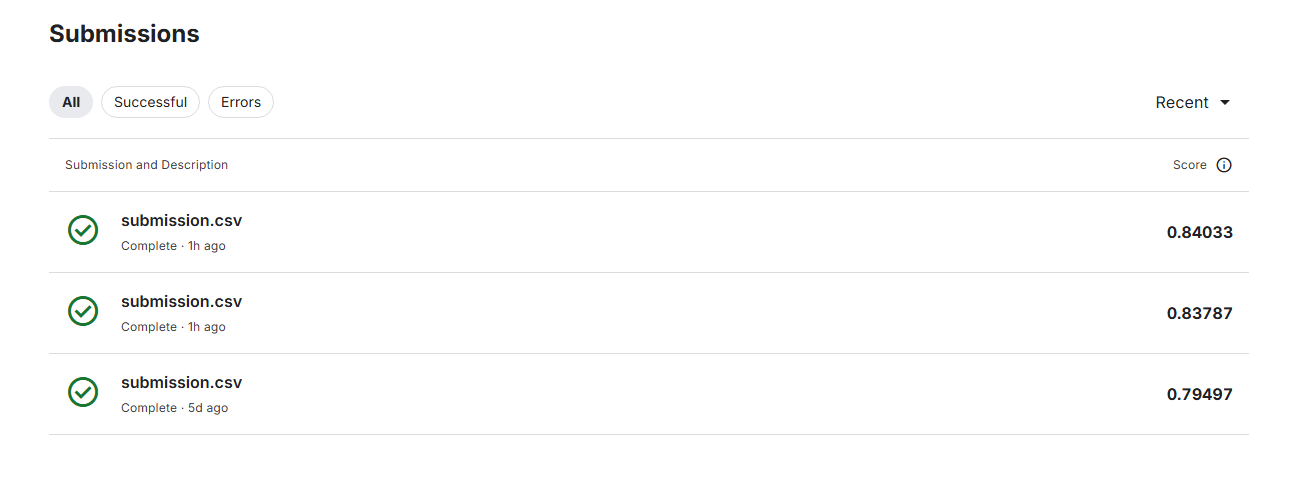